# Experiment 3: Grid Refinement and Approximation Error

In this notebook, we study how the grid size `eta` affects approximation error and runtime.

Our simplex grid function depends directly on `eta`. Therefore, we test several values of `eta` to see how grid refinement changes the average log regret between BCRP and UP.

In [14]:
using CSV
using DataFrames
using LinearAlgebra
using Plots
using Revise
includet("../src.jl")
df= CSV.read("../dataset/prices_6stocks_20years.csv", DataFrame)

# Select the four stocks in the grid refinement experiment
stocks_grid = ["BA", "PG", "KO", "WMT"]
prices_grid= Matrix{Float64}(df[:,stocks_grid])

# We change our eta 
eta_list=[0.25,0.20,0.125,0.10,0.05]

results = DataFrame(eta= Float64[],K= Int[],up_final= Float64[],
    bcrp_final= Float64[],avg_log_regret= Float64[],runtime = Float64[])
n,m = size(prices_grid)
T= n - 1
for eta in eta_list # runtime for UP and BCRP.
    runtime= @elapsed begin
        up_wealth,_,_=uni_port_func(prices_grid, eta)
        _,bcrp_final,_ =bcrp_func_md(prices_grid, eta)
    end
    up_final= up_wealth[end]
    K= length(simplex_grid_md(m, eta))
    avg_log_regret=(log(bcrp_final)-log(up_final))/T
    push!(results, (eta,K,up_final,bcrp_final,avg_log_regret,runtime))
end

println(results)
CSV.write("grid_refinement_results.csv", results)

5×6 DataFrame
 Row │ eta      K      up_final  bcrp_final  avg_log_regret  runtime   
     │ Float64  Int64  Float64   Float64     Float64         Float64   
─────┼─────────────────────────────────────────────────────────────────
   1 │   0.25      35   4.58282     7.46296      9.69462e-5  0.147871
   2 │   0.2       51   4.719       7.51341      9.24638e-5  0.0652476
   3 │   0.125    165   4.67545     7.49725      9.3879e-5   0.145711
   4 │   0.1      269   4.76565     7.51341      9.05083e-5  0.211831
   5 │   0.05    1701   4.77859     7.51492      9.00089e-5  1.38396


"grid_refinement_results.csv"

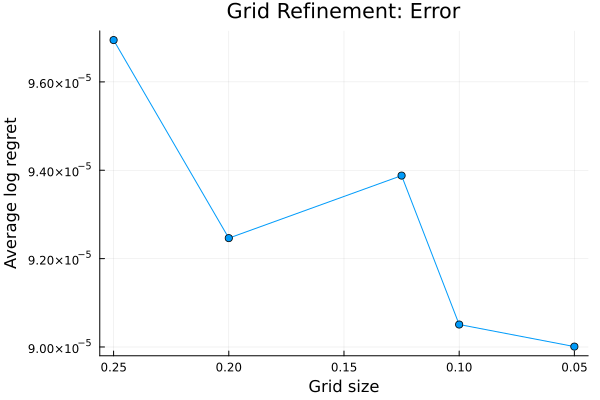

In [9]:
p_error = plot(results.eta,results.avg_log_regret,marker=:circle,
    xlabel = "Grid size",ylabel = "Average log regret",
    title = "Grid Refinement: Error",legend = false,xflip = true)
savefig(p_error,"grid_refinement_error.png")
display(p_error)

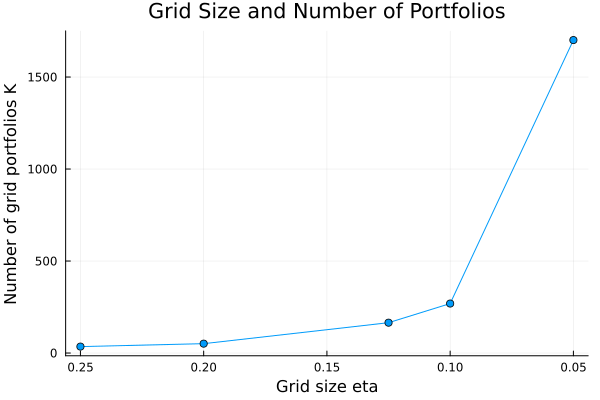

In [13]:
p_K_eta = plot(results.eta,results.K,marker=:circle,
xlabel = "Grid size eta",ylabel = "Number of grid portfolios K",
title = "Grid Size and Number of Portfolios",legend = false,xflip = true)
savefig(p_K_eta, "grid_points_vs_eta.png")
display(p_K_eta)